<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Simulacion-I/blob/main/copia_de_metodolog_a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodología de la Simulación

### 1. Identifique las variables

Aquellas cuyo comportamiento define el comportamiento o la evoución global del sistema real.

### 2. Determine la distribución de probabilidad

Elija el tipo de distribución de probabilidad que mejor defina el comportamiento aleatorio de cada una de las variables del sistema identificadas en el paso anterior.

### 3. Modele las variables aleatorias

Cosntruya un modelo fiel de la aleatoriedad de las variables del sistema. Simular el comportamiento del sistema implica generar muestras aleatorias de cada variable que sigan fielmente la distribución de probabilidad correspondiente.

### 4. Defina el modelo del sistema y los objetivos de la simulación

Fije los objetivos y diseñe un modelo del sistema real que abstraiga sus propiedades más relevantes. Todo error en el modelo (o su implementación computacional) puede dar lugar a conclusiones equivocadas.

Antes de experimentar con el modelo, asegurarse de que refleja fielmente el sistema real **validando** el mismo a partir de datos reales, para ello compare los resultados obtenidos de la simulación con los producidos por el sistema.

### 5. Diseñe el experimento

Diseñe un experimento así como las ejecuciones concretas del mismo, los escenarios que desea estudiar para alcanzar los objetivos fijados. El experimento consiste en generar valores de las variables cuyo comportamiento define el comportamiento del sistema y analizar este ante dichos valores.

### 6. Repita el experimento $n$ veces

Así dispondrá de $n$ observaciones sobre el comportamiento del sistema, lo que permitirá entender su funcionamiento así como evaluar el desempeño del mismo frente a los diversos escenarios establecidos.

El **método Monte Carlo** se basa en la **Ley Fuerte de los Grandes Números** y el **Teorema del Límite Central**.

## Ejemplo

Calcule la probabilidad de que aparezcan dos caras lanzando tres veces una moneda al aire.

1. Analíticamente.
2. Mediante simulación.

Analiticamente:

Los resultados posibles al lanzar la moneda tres veces es $2^3=8$, los eventos posibles, con $A=$ cara y $S=$ cruz:

$$S={(SSS), (SSA), (SAS), (ASS), (SAA), (ASA), (AAS), (AAA)}$$

Los casos favorables son cuando dos tres caras, $AAS$, $SAA$ y $ASA$, entonces:

$$P=\frac{\mathbf{Casos} \hspace{0.2cm} \mathbf{favorables}}{\mathbf{Casos} \hspace{0.2cm} \mathbf{totales}}$$

De lo anterior:

$$P=\frac{3}{8}=0.375$$

De otra forma, podemos obtener la probabilidad usando la distribución binomial:

$$P(X=x)=\binom{n}{x}p^x(1-p)^{n-x}$$

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy.stats

In [ ]:
n = 3  # Número de lanzamientos
k = 2  # Número de caras (éxitos)
p = 0.5  # Probabilidad de obtener cara en un solo lanzamiento

# Calcular la probabilidad usando la función de masa de probabilidad binomial
proba_bino = binom.pmf(k, n, p)

print(f"La probabilidad de obtener {k} caras en {n} lanzamientos con distribución binomial es: {proba_bino:.4f}")

La probabilidad de obtener 2 caras en 3 lanzamientos con distribución binomial es: 0.3750


Por simulación: Construimos el modelo en varios pasos.

**PASO 1**. Defina las variables que intervienen en el modelo.

In [ ]:
def volados(n):
    caras = 0
    for i in range(n):
        u = random.uniform(0,1)
        if u <= 0.5:
            caras += 1
    return caras

In [ ]:
def caras(m):
    favorable = 0
    if volados(3) == m:
        favorable +=1
    return favorable

In [ ]:
def experimento(iteraciones):
    i = 0
    favorables=0
    Lista = []
    while i <= iteraciones:
        favorables = favorables + caras(2)
        i += 1
        probabilidad = favorables/i
        Lista.append(probabilidad)
    return Lista

**PASO 2**. Formule la distribución de probabilidad de cada variable.


|      |**Sol**|**Aguila**|
|------|-------|----------|
|f(x)|    0.5     | 0.5         |

**PASO 3**. Enumere la distribución acumulada de probabilidad de cada variable.

|      |**Sol**|**Aguila**|
|------|-------|----------|
|f(x)  |  0.5     | 0.5         |
|F(x)  |   0.5    |   1       |

**PASO 4**. Establezca el intervalo de números aleatorios correspondiente a cada valor de cada una de las variables.

|           |**Sol**|**Aguila**|
|-----------|-------|----------|
|f(x)       |  0.5     | 0.5         |
|F(x)       |   0.5    |     1     |
|Intervalos |  [0,0.5)     |  [0.5,1]        |

**PASO 5**. Genere números aleatorios.

In [ ]:
r.uniform(0,1)

0.4434012163218115

**PASO 6**. Simule un lanzamiento.

Si Número de caras = 2       

¿Aparecen dos caras? = **1**

Si Número de caras ≠ 2       

¿Aparecen dos caras? = **0**

**PASO 7**. Obtenga la gráfica de estabilización que indica que el tamaño de muestra utilizado es suficiente para
garantizar la convergencia del resultado.

Al realizar varias veces la simulación varias veces con $2000$, me di cuenta que con $1250$ era suficiente:

In [ ]:
exp = experimento(750)

In [ ]:
np.mean(exp)

np.float64(0.37526631897208507)

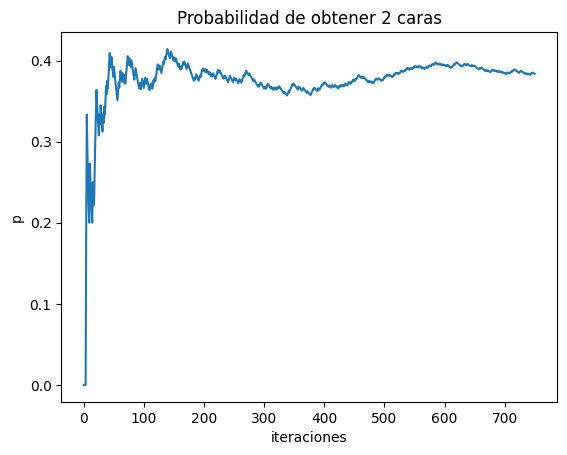

In [ ]:
plt.plot(exp)
plt.xlabel('iteraciones')
plt.ylabel('p')
plt.title('Probabilidad de obtener 2 caras')
plt.show()

**PASO 8**. Replique el modelo.

In [ ]:
def simulacion_caras(repeticiones):
    List = []
    for i in range(repeticiones):
        List.append(np.mean(experimento(1000)))
    return List

In [ ]:
simulacion = simulacion_caras(50)

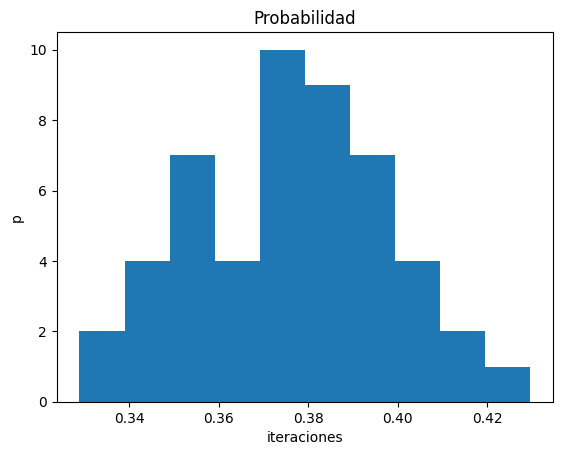

In [ ]:
plt.hist(simulacion)
plt.xlabel('iteraciones')
plt.ylabel('p')
plt.title('Probabilidad')
plt.show()

**PASO 9**. Calcule la probabilidad de que aparezcan dos caras lanzando tres veces una moneda al aire y su desviación
estándar.

In [ ]:
np.mean(simulacion), np.var(simulacion), np.std(simulacion)

(np.float64(0.3757994008012719),
 np.float64(0.0004727343364693384),
 np.float64(0.021742454702018778))

**PASO 10**. Halle el intervalo de confianza de la probabilidad de que aparezcan dos caras lanzando tres veces una moneda
al aire con un nivel de confianza del $95 \%$.

In [ ]:
media_simulacion = np.mean(simulacion)
std_simulacion = np.std(simulacion)

n_repeticiones = len(simulacion)

error_estandar = std_simulacion / np.sqrt(n_repeticiones)

intervalo_confianza = norm.interval(0.95, loc=media_simulacion, scale=error_estandar)

print(f"Media de la simulación: {media_simulacion:.4f}")
print(f"Desviación estándar de la simulación: {std_simulacion:.4f}")
print(f"Intervalo de confianza del 95% para la probabilidad: ({intervalo_confianza[0]:.4f}, {intervalo_confianza[1]:.4f})")

Media de la simulación: 0.3758
Desviación estándar de la simulación: 0.0217
Intervalo de confianza del 95% para la probabilidad: (0.3698, 0.3818)


# Task
Perform a Shapiro-Wilk test on the `simulacion` data to assess its normality, and then create a histogram of this data with an overlaid fitted normal distribution curve for visual inspection. Finally, based on both the statistical test and the visualization, determine whether the `simulacion` data can be considered normally distributed.

## Test for Normality

### Subtask:
Perform a statistical test (e.g., Shapiro-Wilk test) to assess if the `simulacion` data follows a normal distribution. The null hypothesis is that the data is normally distributed.


**Reasoning**:
To perform the Shapiro-Wilk test, I will import the `shapiro` function from `scipy.stats` and apply it to the `simulacion` data, then print the results.



In [ ]:
from scipy.stats import shapiro

# Perform the Shapiro-Wilk test
shapiro_statistic, shapiro_pvalue = shapiro(simulacion)

print(f"Shapiro-Wilk Test Statistic: {shapiro_statistic:.4f}")
print(f"Shapiro-Wilk P-value: {shapiro_pvalue:.4f}")

Shapiro-Wilk Test Statistic: 0.9867
Shapiro-Wilk P-value: 0.8420


**Reasoning**:
Now that the Shapiro-Wilk test has been performed, I will create a histogram of the `simulacion` data and overlay a fitted normal distribution curve to visually inspect its normality. This addresses the second part of the subtask.



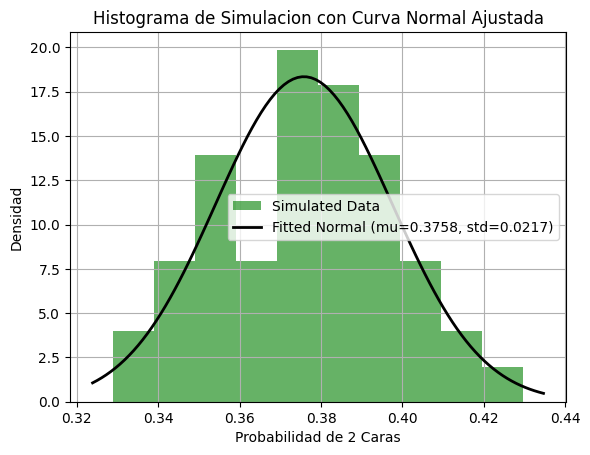

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Plot histogram of the simulated data
plt.hist(simulacion, bins=10, density=True, alpha=0.6, color='g', label='Simulated Data')

# Fit a normal distribution to the data
mu, std = norm.fit(simulacion)

# Plot the PDF of the fitted normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Fitted Normal (mu={mu:.4f}, std={std:.4f})')

plt.xlabel('Probabilidad de 2 Caras')
plt.ylabel('Densidad')
plt.title('Histograma de Simulacion con Curva Normal Ajustada')
plt.legend()
plt.grid(True)
plt.show()

### Conclusion on Normality

**Statistical Test (Shapiro-Wilk Test)**:
- Shapiro-Wilk Test Statistic: 0.9867
- Shapiro-Wilk P-value: 0.8420

Since the p-value (0.8420) is significantly greater than the common significance level of 0.05, we **do not reject the null hypothesis**. This suggests that there is no significant evidence to conclude that the `simulacion` data is not normally distributed.

**Visual Inspection (Histogram with Fitted Normal Curve)**:
The histogram of the `simulacion` data, with the fitted normal distribution curve overlaid, shows that the data points generally follow the shape of a normal distribution. The curve aligns well with the distribution of the bars, indicating a good visual fit.

**Overall Conclusion**:
Based on both the statistical evidence from the Shapiro-Wilk test and the visual confirmation from the histogram, the `simulacion` data can be **considered normally distributed**.

## Final Task

### Subtask:
Summarize the results of the normality test and the visual inspection, explaining whether the `simulacion` data can be considered normally distributed, and reiterate why a binomial test is not applicable to this data.


## Summary:

### Q&A
*   The `simulacion` data can be considered normally distributed. Both the statistical Shapiro-Wilk test and the visual inspection of the histogram with an overlaid normal curve support this conclusion.
*   A binomial test is not applicable to this data because the `simulacion` data is continuous (or approximates continuous) and follows a normal distribution. The binomial distribution is appropriate for discrete data representing the number of successes in a fixed number of independent Bernoulli trials, which does not align with the characteristics of this dataset.

### Data Analysis Key Findings
*   The Shapiro-Wilk test for normality yielded a test statistic of 0.9867 and a p-value of 0.8420.
*   Since the p-value (0.8420) is significantly greater than the common significance level of 0.05, the null hypothesis, stating that the data is normally distributed, was not rejected.
*   Visual inspection of the data's histogram, with an overlaid fitted normal distribution curve, confirmed a good visual fit, indicating that the data points generally follow the shape of a normal distribution.

### Insights or Next Steps
*   Given the `simulacion` data's normal distribution, future statistical analyses can confidently utilize parametric tests that assume normality, potentially leading to more robust conclusions.
*   The confirmed normality of the data reinforces the inappropriateness of using a binomial test, guiding towards more suitable analytical methods for continuous data.
